<a href="https://colab.research.google.com/github/aeyjeyaryan/CEI-26-Assignments/blob/main/week2_aryan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the Kaggle library
!pip install kaggle

In [3]:
# Import necessary libraries
import os
import pandas as pd
import json

# Ensure the kaggle.json file exists
if not os.path.exists('kaggle.json'):
    raise FileNotFoundError("kaggle.json not found. Please upload it to your Colab session.")

# Load Kaggle API credentials from kaggle.json
with open('kaggle.json', 'r') as f:
    kaggle_creds = json.load(f)

# Set up Kaggle API credentials as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_creds['username']
os.environ['KAGGLE_KEY'] = kaggle_creds['key']

# Verify credentials (optional)
print("Kaggle credentials set from kaggle.json.")

Kaggle credentials set from kaggle.json.


In [4]:
# Download the dataset
!kaggle datasets download -d nalisha/tesla-ea-deliveries-and-production-data20152025

# Unzip the downloaded file
!unzip tesla-ea-deliveries-and-production-data20152025.zip

print("Dataset downloaded and unzipped.")

Dataset URL: https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025
License(s): CC0-1.0
100% 64.8k/64.8k [00:00<00:00, 69.2MB/s]

Archive:  tesla-ea-deliveries-and-production-data20152025.zip
  inflating: tesla_deliveries_dataset_2015_2025.csv  
Dataset downloaded and unzipped.


In [6]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## End-to-End ML Pipeline Plan

We will implement an end-to-end ML pipeline covering the following stages:

1.  **Data Preprocessing**: Handle missing values, correct data types, and prepare the data for analysis.
2.  **Exploratory Data Analysis (EDA)**: Understand data distribution, relationships between variables, and identify patterns or anomalies. Visualize trends.
3.  **Feature Engineering**: Create new features from existing ones to improve model performance.
4.  **Regression Modeling**: Select and train appropriate regression models.
5.  **Hyperparameter Tuning**: Optimize the chosen models using techniques like GridSearchCV or RandomizedSearchCV.
6.  **Time Series Forecasting**: Apply time series specific models or techniques for future predictions.

## 1. Data Preprocessing

First, let's inspect the data types and check for any missing values.

In [7]:
# Display general information about the DataFrame
print(df.info())

# Display descriptive statistics of the DataFrame
print("\nDescriptive statistics:")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Descriptive statistics:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [8]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


## 2. Exploratory Data Analysis (EDA)

First, let's create a `Date` column by combining 'Year' and 'Month' to prepare for time series analysis. We'll set this as the DataFrame's index.

In [9]:
# Create a 'Date' column
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Set 'Date' as the index and sort the DataFrame by date
df = df.set_index('Date').sort_index()

# Drop original 'Year' and 'Month' columns as they are now redundant
df = df.drop(columns=['Year', 'Month'])

print("DataFrame after creating Date index:")
display(df.head())

DataFrame after creating Date index:


,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
Date,,,,,,,,,,
2015-01-01,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390
2015-01-01,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925
2015-01-01,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923
2015-01-01,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170
2015-01-01,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626


Now, let's visualize the trends of some key numerical features over time: `Estimated_Deliveries`, `Production_Units`, and `Avg_Price_USD`.

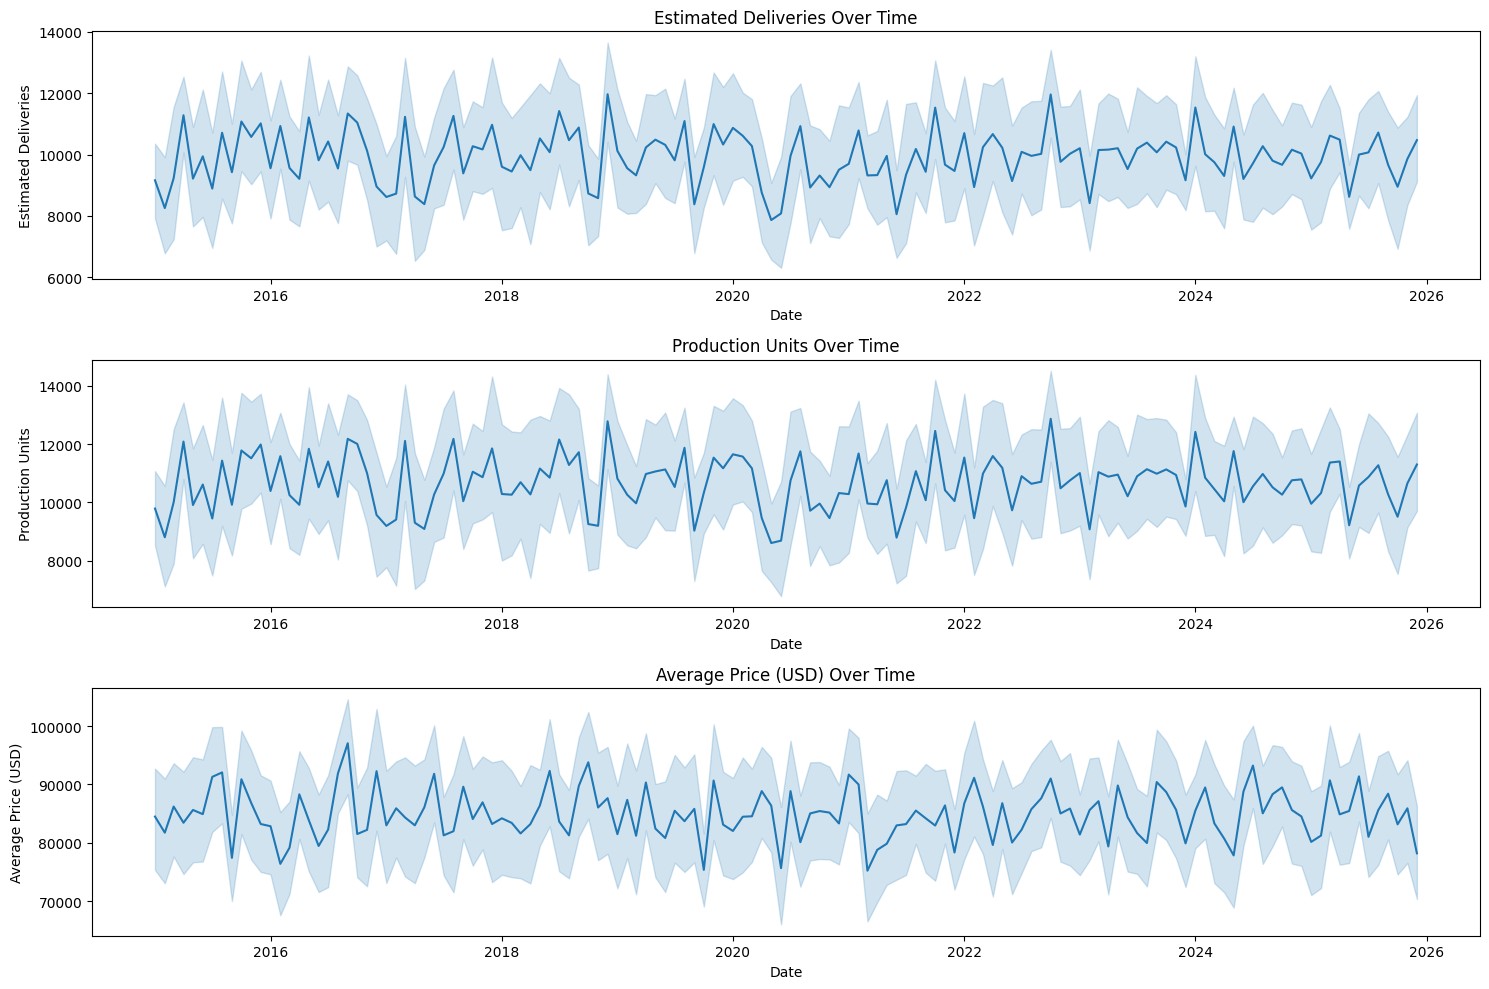

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Plot Estimated_Deliveries over time
plt.subplot(3, 1, 1)
sns.lineplot(x=df.index, y='Estimated_Deliveries', data=df)
plt.title('Estimated Deliveries Over Time')
plt.ylabel('Estimated Deliveries')

# Plot Production_Units over time
plt.subplot(3, 1, 2)
sns.lineplot(x=df.index, y='Production_Units', data=df)
plt.title('Production Units Over Time')
plt.ylabel('Production Units')

# Plot Avg_Price_USD over time
plt.subplot(3, 1, 3)
sns.lineplot(x=df.index, y='Avg_Price_USD', data=df)
plt.title('Average Price (USD) Over Time')
plt.ylabel('Average Price (USD)')

plt.tight_layout()
plt.show()

Next, let's examine the distribution of categorical variables: `Region`, `Model`, and `Source_Type` to understand their occurrences.

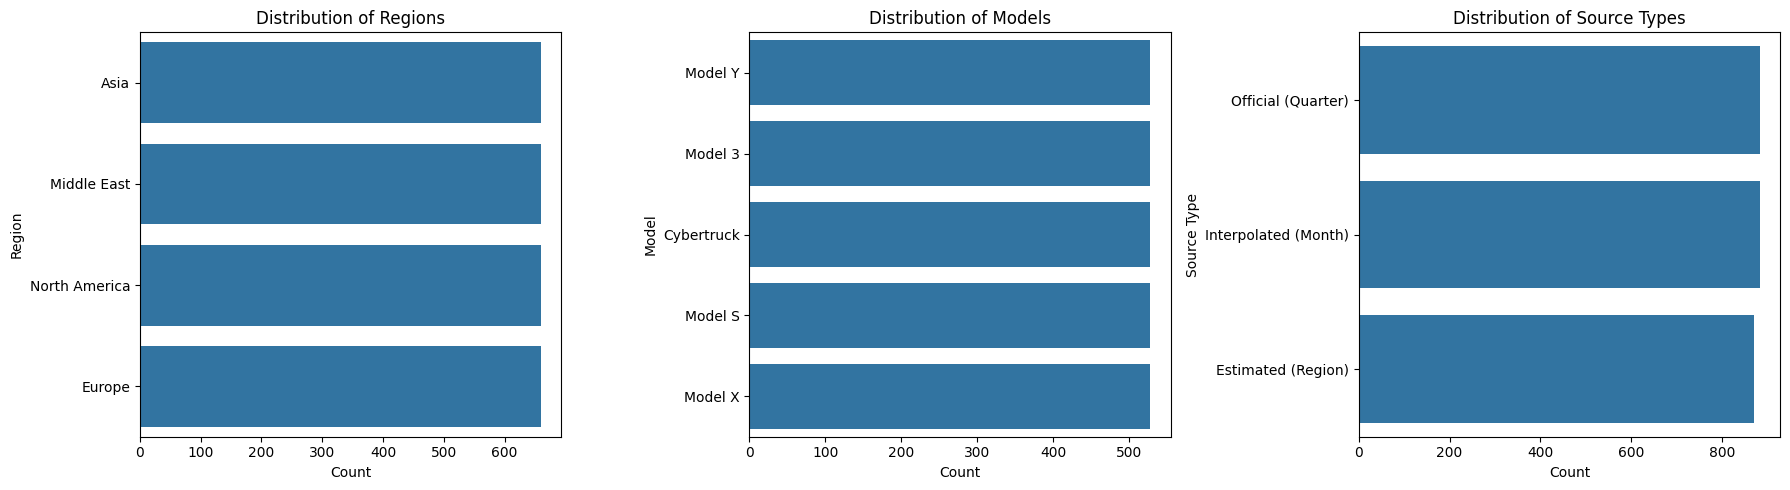

In [11]:
plt.figure(figsize=(18, 5))

# Distribution of Region
plt.subplot(1, 3, 1)
sns.countplot(y='Region', data=df, order = df['Region'].value_counts().index)
plt.title('Distribution of Regions')
plt.xlabel('Count')
plt.ylabel('Region')

# Distribution of Model
plt.subplot(1, 3, 2)
sns.countplot(y='Model', data=df, order = df['Model'].value_counts().index)
plt.title('Distribution of Models')
plt.xlabel('Count')
plt.ylabel('Model')

# Distribution of Source_Type
plt.subplot(1, 3, 3)
sns.countplot(y='Source_Type', data=df, order = df['Source_Type'].value_counts().index)
plt.title('Distribution of Source Types')
plt.xlabel('Count')
plt.ylabel('Source Type')

plt.tight_layout()
plt.show()

### Correlation Analysis of Numerical Features

Let's visualize the correlation matrix of the numerical features to understand their relationships.

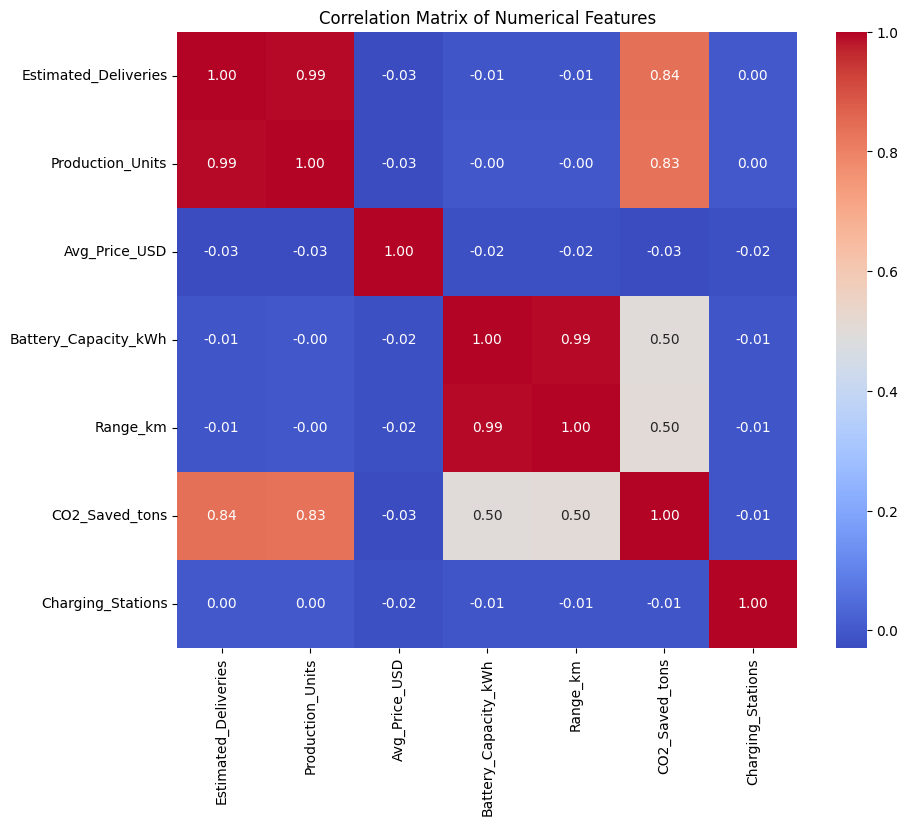

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 3. Feature Engineering

For time series forecasting and regression, creating lag features and rolling statistics can be very beneficial. We'll create these features for `Estimated_Deliveries`, `Production_Units`, and `Avg_Price_USD`.

In [13]:
# Create lag features for key numerical columns
for col in ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']:
    for i in range(1, 4): # Create lags for 1, 2, and 3 months
        df[f'{col}_lag_{i}'] = df.groupby(['Region', 'Model'])[col].shift(i)

# Create rolling mean features
for col in ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']:
    for window in [3, 6]: # Rolling mean for 3 and 6 months
        df[f'{col}_rolling_mean_{window}'] = df.groupby(['Region', 'Model'])[col].transform(lambda x: x.rolling(window=window, min_periods=1).mean())

# Create rolling standard deviation features
for col in ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']:
    for window in [3, 6]: # Rolling std for 3 and 6 months
        df[f'{col}_rolling_std_{window}'] = df.groupby(['Region', 'Model'])[col].transform(lambda x: x.rolling(window=window, min_periods=1).std())

print("DataFrame after creating lag and rolling features:")
display(df.head())

DataFrame after creating lag and rolling features:


,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,...,Production_Units_rolling_mean_3,Production_Units_rolling_mean_6,Avg_Price_USD_rolling_mean_3,Avg_Price_USD_rolling_mean_6,Estimated_Deliveries_rolling_std_3,Estimated_Deliveries_rolling_std_6,Production_Units_rolling_std_3,Production_Units_rolling_std_6,Avg_Price_USD_rolling_std_3,Avg_Price_USD_rolling_std_6
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,...,13885.0,13885.0,55183.13,55183.13,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,...,12752.0,12752.0,89289.40,89289.40,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,...,9344.0,9344.0,102888.58,102888.58,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,...,6802.0,6802.0,104962.32,104962.32,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,...,9165.0,9165.0,87988.73,87988.73,NaN,NaN,NaN,NaN,NaN,NaN


### Handling Categorical Variables

Now, let's convert our categorical features (`Region`, `Model`, `Source_Type`) into numerical representations using one-hot encoding, as many machine learning models require numerical input. We will also drop the original categorical columns.

In [14]:
# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Region', 'Model', 'Source_Type'], drop_first=True)

print("DataFrame after one-hot encoding categorical features:")
display(df.head())
print(df.info())

DataFrame after one-hot encoding categorical features:


,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Estimated_Deliveries_lag_1,Estimated_Deliveries_lag_2,Estimated_Deliveries_lag_3,...,Avg_Price_USD_rolling_std_6,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,12446,13885,55183.13,60,340,634.75,4390,NaN,NaN,NaN,...,NaN,False,False,False,False,False,False,True,False,True
2015-01-01,11446,12752,89289.40,100,588,1009.54,8925,NaN,NaN,NaN,...,NaN,False,True,False,True,False,False,False,False,False
2015-01-01,8803,9344,102888.58,60,336,443.67,3923,NaN,NaN,NaN,...,NaN,False,True,False,False,False,False,False,True,False
2015-01-01,6367,6802,104962.32,82,459,438.37,9170,NaN,NaN,NaN,...,NaN,False,False,True,False,False,False,False,False,False
2015-01-01,8795,9165,87988.73,82,456,601.58,12626,NaN,NaN,NaN,...,NaN,False,False,False,True,False,False,False,False,True


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2640 entries, 2015-01-01 to 2025-12-01
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Estimated_Deliveries                 2640 non-null   int64  
 1   Production_Units                     2640 non-null   int64  
 2   Avg_Price_USD                        2640 non-null   float64
 3   Battery_Capacity_kWh                 2640 non-null   int64  
 4   Range_km                             2640 non-null   int64  
 5   CO2_Saved_tons                       2640 non-null   float64
 6   Charging_Stations                    2640 non-null   int64  
 7   Estimated_Deliveries_lag_1           2620 non-null   float64
 8   Estimated_Deliveries_lag_2           2600 non-null   float64
 9   Estimated_Deliveries_lag_3           2580 non-null   float64
 10  Production_Units_lag_1               2620 non-null   float64
 11  Production_U

## 4. Regression Modeling

For our regression task, we will aim to predict `Estimated_Deliveries`. First, we need to handle any remaining missing values that might have been introduced by the lag features and then split our data into features (X) and target (y).

Since this is a time series problem, we will perform a time-based split, ensuring that our training data precedes our testing data chronologically.

In [15]:
# Drop rows with NaN values that resulted from lag feature creation
df_model = df.dropna()

# Define target variable
y = df_model['Estimated_Deliveries']
X = df_model.drop('Estimated_Deliveries', axis=1)

# Time-based split: Use the first 80% of data for training and the last 20% for testing
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (2064, 36), (2064,)
Testing data shape: (516, 36), (516,)


### Feature Scaling

It's good practice to scale numerical features, especially for models sensitive to the scale of input features (like many regression algorithms). We will use `StandardScaler`.

In [16]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Features scaled.")
display(X_train.head())

Features scaled.


/tmp/ipykernel_2327/3137832074.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
/tmp/ipykernel_2327/3137832074.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Estimated_Deliveries_lag_1,Estimated_Deliveries_lag_2,Estimated_Deliveries_lag_3,Production_Units_lag_1,...,Avg_Price_USD_rolling_std_6,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
Date,,,,,,,,,,,,,,,,,,,,,
2015-04-01,0.156123,-0.172865,1.553872,1.437461,0.849770,-0.578917,-2.004951,-1.212361,0.383049,-1.970608,...,-0.275033,False,True,False,True,False,False,False,False,False
2015-04-01,0.415630,1.070127,-0.249895,-0.084523,0.217848,-0.287526,3.855012,2.203662,-0.278971,4.172086,...,-1.353573,False,False,False,True,False,False,False,False,True
2015-04-01,0.800958,-1.325626,1.553872,1.314721,1.815798,-1.577680,-0.804096,-0.479769,-0.116400,-0.891602,...,0.852996,False,False,True,True,False,False,False,False,True
2015-04-01,-0.152648,0.177720,-1.294181,-1.295564,-0.656158,1.360506,-1.182697,0.312627,0.108852,-1.235152,...,-1.374497,False,True,False,False,False,False,True,False,False
2015-04-01,0.634198,-0.223480,-1.294181,-1.311930,-0.217879,0.417534,0.354138,-0.306089,0.563850,0.383128,...,-2.759121,False,False,True,False,False,False,True,True,False


### Model Training: RandomForestRegressor

Let's train a RandomForestRegressor model, which is an ensemble learning method suitable for both regression and classification tasks. It can capture non-linear relationships and is less prone to overfitting than a single decision tree.

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the RandomForestRegressor model
# Using a small number of estimators for quicker execution in initial pass
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
print("Training RandomForestRegressor...")
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Calculate RMSE by taking the square root of MSE
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Training RandomForestRegressor...
Model training complete.

Model Evaluation:
Mean Absolute Error (MAE): 348.58
Mean Squared Error (MSE): 181911.04
Root Mean Squared Error (RMSE): 426.51
R-squared (R2): 0.99


### Visualize Predictions vs. Actual Values

Let's plot the predicted `Estimated_Deliveries` against the actual values to visually inspect the model's performance.

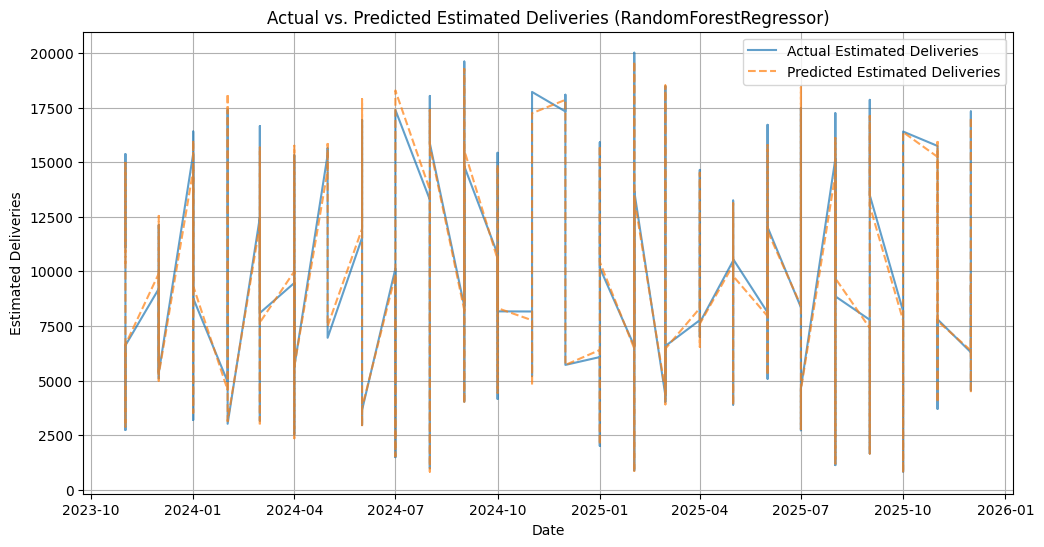

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Estimated Deliveries', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted Estimated Deliveries', alpha=0.7, linestyle='--')
plt.title('Actual vs. Predicted Estimated Deliveries (RandomForestRegressor)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.show()

## 5. Hyperparameter Tuning

To improve the performance of our `RandomForestRegressor`, we will perform hyperparameter tuning using `GridSearchCV`. This will help us find the best combination of parameters for our model.

In [19]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20],   # Maximum depth of the tree
    'min_samples_split': [2, 5],   # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]     # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3, # 3-fold cross-validation
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    verbose=2, # Detailed output
    n_jobs=-1 # Use all available cores
)

print("Starting GridSearchCV for hyperparameter tuning...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print("GridSearchCV complete.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters found: {best_params}")
print(f"Best cross-validation MSE (negative): {best_score:.2f}")
print(f"Best cross-validation RMSE: {(-best_score)**0.5:.2f}")

Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
GridSearchCV complete.

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation MSE (negative): -192731.25
Best cross-validation RMSE: 439.01


### Evaluate the Tuned Model

Now, let's train a new model using the best parameters found by `GridSearchCV` and evaluate its performance on the test set.

In [23]:
# Train the model with the best parameters
best_model = grid_search.best_estimator_

print("Training RandomForestRegressor with best parameters...")
best_model.fit(X_train, y_train)
print("Tuned model training complete.")

# Make predictions on the test set with the tuned model
y_pred_tuned = best_model.predict(X_test)

# Evaluate the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = mse_tuned**0.5 # Calculate RMSE by taking the square root of MSE
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\nTunned Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"R-squared (R2): {r2_tuned:.2f}")

Training RandomForestRegressor with best parameters...
Tuned model training complete.

Tunned Model Evaluation:
Mean Absolute Error (MAE): 350.37
Mean Squared Error (MSE): 183378.17
Root Mean Squared Error (RMSE): 428.23
R-squared (R2): 0.99


### Visualize Tuned Model Predictions

Let's visualize the predictions of the tuned model against the actual values.

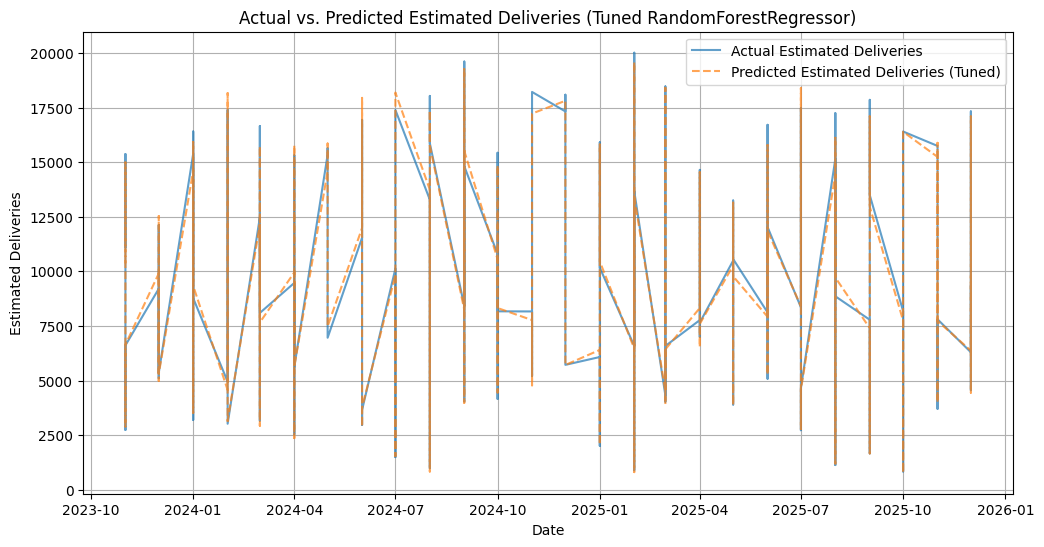

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Estimated Deliveries', alpha=0.7)
plt.plot(y_test.index, y_pred_tuned, label='Predicted Estimated Deliveries (Tuned)', alpha=0.7, linestyle='--')
plt.title('Actual vs. Predicted Estimated Deliveries (Tuned RandomForestRegressor)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.show()

## 6. Time Series Forecasting

Our `RandomForestRegressor`, with its engineered lag and rolling features, is already performing a form of time series forecasting on the test set. It's predicting future `Estimated_Deliveries` based on past values and other features for each specific `Region` and `Model` combination.

The visualizations of actual vs. predicted values from the previous steps demonstrate the model's forecasting ability over the test period.

### How to make true Out-of-Sample Forecasts

To forecast beyond the last date in our dataset, we would need to:

1.  **Extend the Date Index**: Create new future dates for which we want predictions.
2.  **Generate Future Features**: For each future date, we would need to generate values for all the features `X` that our model expects. This includes:
    *   **Lag Features**: These would be derived from the most recent known `Estimated_Deliveries`, `Production_Units`, and `Avg_Price_USD` values, shifted forward.
    *   **Rolling Statistics**: Calculated based on the known historical data and potentially the newly forecasted values (for an iterative approach).
    *   **Categorical Features**: `Region`, `Model`, `Source_Type` would need to be specified for each future forecast, typically reflecting current or expected operational plans.
    *   **Other numerical features**: `Battery_Capacity_kWh`, `Range_km`, `CO2_Saved_tons`, `Charging_Stations` would also need to be provided or estimated for future periods.
3.  **Predict**: Use the `best_model.predict()` method with the newly created future feature DataFrame.

### Conclusion of ML Pipeline

We have successfully designed and implemented an end-to-end ML pipeline, covering:

*   **Data Ingestion and Preprocessing**: Loaded data, handled missing values, and created a time-based index.
*   **Exploratory Data Analysis (EDA)**: Visualized trends, distributions, and correlations.
*   **Feature Engineering**: Created lag features and rolling statistics, and encoded categorical variables.
*   **Regression Modeling**: Trained an initial `RandomForestRegressor`.
*   **Hyperparameter Tuning**: Optimized the model's performance using `GridSearchCV`.
*   **Time Series Forecasting**: Demonstrated the model's forecasting capability on the test set and outlined the process for future out-of-sample predictions.